In [4]:
import numpy as np
import matplotlib.pyplot as plt

import tracker.kalmanfilter as KF
import tracker.utilities as Util

In [15]:
# Generated toy hits
N_events=5000

Hit_collection={}
Truth_collection ={}
ParTruth_collection={}

for i in range(N_events):
    Hit_collection[i],Truth_collection[i],ParTruth_collection[i] = \
            Util.hit.gen_hits(x0=0,y0=0,z0=0, t0=0, Ax=0.3,Az=0.2,At=1/30,  N_LAYERS=4)

Kalman result [Ax, Az, At]: [22.65602437 15.83381388  2.84952187  0.30780265  0.197029    0.03416795]
LS fit result [Ax, Az, At]: [22.655980776302997, 15.833764522840212, 2.8495718595701316, 0.3078021076345477, 0.19703580124937897, 0.03416664744803902]


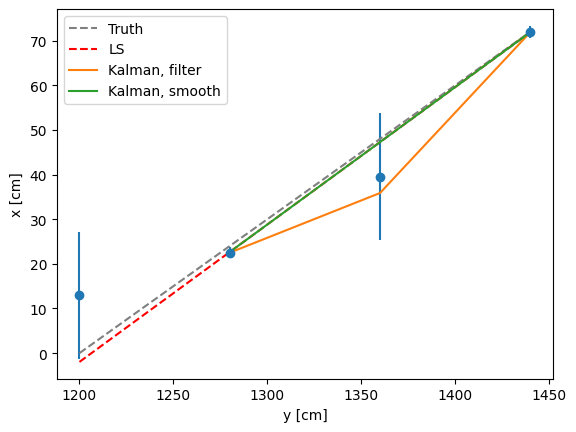

In [22]:
hits = Hit_collection[0]
hits_truth = Truth_collection[0]

# Run Kalman filter
kf = Util.track.run_kf(hits)
# Run LS fit
guess = Util.track.guess_track(hits)
fit_ls = Util.track.fit_track(hits,guess)

print(f"Kalman result [Ax, Az, At]: {kf.Xsm[0][:]}")
print(f"LS fit result [Ax, Az, At]: {fit_ls.values[:]}")

# Digitized hit
hit_x = [hit.x for hit in hits]
hit_y = [hit.y for hit in hits]
hit_z = [hit.z for hit in hits]
hit_t = [hit.t for hit in hits]
hit_x_err = [hit.x_err for hit in hits]
hit_y_err = [hit.y_err for hit in hits]
hit_z_err = [hit.z_err for hit in hits]
hit_t_err = [hit.t_err for hit in hits]

# Truth
hit_truth_x = np.array([hit.x for hit in hits_truth])
hit_truth_y = np.array([hit.y for hit in hits_truth])
hit_truth_z = np.array([hit.z for hit in hits_truth])
hit_truth_t = np.array([hit.t for hit in hits_truth])


# Kalman-Filtred
fit_x = [hit[0] for hit in kf.Xf]
fit_z = [hit[1] for hit in kf.Xf]
fit_t = [hit[2] for hit in kf.Xf]

# Kalman-Smoothed
smooth_x = [hit[0] for hit in kf.Xsm]
smooth_z = [hit[1] for hit in kf.Xsm]
smooth_t = [hit[2] for hit in kf.Xsm]

# LS fit
fit1_res = list(fit_ls.values)
fit_ls_x = fit1_res[0]+fit1_res[3]*(hit_truth_y-hits[1].y)
fit_ls_z = fit1_res[1]+fit1_res[4]*(hit_truth_y-hits[1].y)
fit_ls_t = fit1_res[2]+fit1_res[5]*(hit_truth_y-hits[1].y)




plt.errorbar(hit_y, hit_x, yerr=hit_x_err, fmt="o")
plt.plot(hit_truth_y, hit_truth_x, color="grey", linestyle="--", label="Truth")
plt.plot(hit_truth_y, fit_ls_x,    color="r", linestyle="--", label="LS")
plt.plot(hit_y[1:], fit_x, label="Kalman, filter")
plt.plot(hit_y[1:], smooth_x, label="Kalman, smooth")
plt.xlabel("y [cm]")
plt.ylabel("x [cm]")
plt.legend()
plt.show()